In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.simplefilter("ignore")

### Dataset Initialization

In [60]:
result_df = pd.read_csv('formula-1-world-championship-1950-2020/results.csv') 
qualifying_df = pd.read_csv('formula-1-world-championship-1950-2020/qualifying.csv')
pit_stops_df = pd.read_csv('formula-1-world-championship-1950-2020/pit_stops.csv')
drivers_df = pd.read_csv('formula-1-world-championship-1950-2020/drivers.csv')
races_df = pd.read_csv('formula-1-world-championship-1950-2020/races.csv')
constructor_df = pd.read_csv('formula-1-world-championship-1950-2020/constructors.csv')
driver_standings_df = pd.read_csv('formula-1-world-championship-1950-2020/driver_standings.csv')
constructor_standings_df = pd.read_csv('formula-1-world-championship-1950-2020/constructor_standings.csv')
circuits_df = pd.read_csv('formula-1-world-championship-1950-2020/circuits.csv')
lap_times_df = pd.read_csv('formula-1-world-championship-1950-2020/lap_times.csv')
sprint_results_df = pd.read_csv('formula-1-world-championship-1950-2020/sprint_results.csv')

### Dataset Information

In [61]:
datasets = {
    "Results": result_df,
    "Races": races_df,
    "Drivers": drivers_df,
    "Constructors": constructor_df,
    "Qualifying": qualifying_df,
    "Pit Stops": pit_stops_df,
    "Driver Standings": driver_standings_df,
    "Constructor Standings": constructor_standings_df,
    "Circuits": circuits_df,
    "Lap Times": lap_times_df,
    "Sprint Results": sprint_results_df
}

for name, df in datasets.items():
    print("\n" + "="*70)
    print(f"DATASET: {name}")
    print("="*70)
    df.info()


DATASET: Results
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         26759 non-null  int64  
 1   raceId           26759 non-null  int64  
 2   driverId         26759 non-null  int64  
 3   constructorId    26759 non-null  int64  
 4   number           26759 non-null  object 
 5   grid             26759 non-null  int64  
 6   position         26759 non-null  object 
 7   positionText     26759 non-null  object 
 8   positionOrder    26759 non-null  int64  
 9   points           26759 non-null  float64
 10  laps             26759 non-null  int64  
 11  time             26759 non-null  object 
 12  milliseconds     26759 non-null  object 
 13  fastestLap       26759 non-null  object 
 14  rank             26759 non-null  object 
 15  fastestLapTime   26759 non-null  object 
 16  fastestLapSpeed  26759 non-null  object 

# FEATURE ENGINEERING

### Target Variable Creation

In [62]:
result_df['position_num'] = pd.to_numeric(result_df['position'], errors='coerce')
result_df['podium'] = (result_df['position_num'] <= 3).astype(int) # 1 for podium finish, 0 otherwise
print(result_df['podium'].value_counts())
print(result_df['podium'].dtype)

podium
0    23363
1     3396
Name: count, dtype: int64
int64


### Feature Renaming

In [63]:
qualifying_df = qualifying_df.rename(columns={'position': 'quali_position'})
constructor_df = constructor_df.rename(columns={'nationality': 'construct_nationality'}) #team ka naam 

### Merging of Result, Races, Qualifying, Constructor, Drivers Datasets

In [64]:
print("Results year range:",
      races_df.merge(result_df, on='raceId')['year'].min(),
      races_df.merge(result_df, on='raceId')['year'].max())

print("Races year range:",
      races_df['year'].min(),
      races_df['year'].max())

Results year range: 1950 2024
Races year range: 1950 2024


In [65]:
df = (
    result_df
    .merge(races_df[['raceId', 'year', 'round', 'circuitId', 'name', 'date']], on='raceId', how='left')
    .merge(qualifying_df[['raceId', 'driverId', 'quali_position']], on=['raceId','driverId'], how='left')
    .merge(constructor_df[['constructorId', 'construct_nationality']], on='constructorId', how='left')
    .merge(drivers_df[['driverId', 'nationality', 'dob','forename','surname']], on='driverId', how='left')
)

In [66]:
df['year'].min()

1950

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   resultId               26759 non-null  int64  
 1   raceId                 26759 non-null  int64  
 2   driverId               26759 non-null  int64  
 3   constructorId          26759 non-null  int64  
 4   number                 26759 non-null  object 
 5   grid                   26759 non-null  int64  
 6   position               26759 non-null  object 
 7   positionText           26759 non-null  object 
 8   positionOrder          26759 non-null  int64  
 9   points                 26759 non-null  float64
 10  laps                   26759 non-null  int64  
 11  time                   26759 non-null  object 
 12  milliseconds           26759 non-null  object 
 13  fastestLap             26759 non-null  object 
 14  rank                   26759 non-null  object 
 15  fa

In [69]:
df.sort_values('year').head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,round,circuitId,name,date,quali_position,construct_nationality,nationality,dob,forename,surname
20034,20035,833,660,154,18,21,11,11,11,0.0,...,1,9,British Grand Prix,1950-05-13,NaN,French,Belgian,1916-08-11,Johnny,Claes
20178,20179,835,529,113,17,9,5,5,5,1.0,...,3,19,Indianapolis 500,1950-05-30,NaN,American,American,1916-09-12,Tony,Bettenhausen
20177,20178,833,666,151,9,10,\N,R,20,0.0,...,1,9,British Grand Prix,1950-05-13,NaN,British,British,1918-10-16,Tony,Rolt
20176,20177,833,788,105,10,20,10,10,10,0.0,...,1,9,British Grand Prix,1950-05-13,NaN,Italian,British,1915-10-26,Joe,Fry
20175,20176,839,697,163,52,23,\N,W,27,0.0,...,7,14,Italian Grand Prix,1950-09-03,NaN,Italian,Italian,1903-06-09,Felice,Bonetto


In [67]:
df.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,round,circuitId,name,date,quali_position,construct_nationality,nationality,dob,forename,surname
0,1,18,1,1,22,1,1,1,1,10.0,...,1,1,Australian Grand Prix,2008-03-16,1.0,British,British,1985-01-07,Lewis,Hamilton
1,2,18,2,2,3,5,2,2,2,8.0,...,1,1,Australian Grand Prix,2008-03-16,5.0,German,German,1977-05-10,Nick,Heidfeld
2,3,18,3,3,7,7,3,3,3,6.0,...,1,1,Australian Grand Prix,2008-03-16,7.0,British,German,1985-06-27,Nico,Rosberg
3,4,18,4,4,5,11,4,4,4,5.0,...,1,1,Australian Grand Prix,2008-03-16,12.0,French,Spanish,1981-07-29,Fernando,Alonso
4,5,18,5,1,23,3,5,5,5,4.0,...,1,1,Australian Grand Prix,2008-03-16,3.0,British,Finnish,1981-10-19,Heikki,Kovalainen


In [70]:
df = df.sort_values('year')

### Feature Datatype Change

In [71]:
print(df['grid'].dtype)
print(df['dob'].dtype)
print(df['date'].dtype)

int64
object
object


In [72]:
df['grid'] = pd.to_numeric(df['grid'], errors='coerce')
df['dob'] = pd.to_datetime(df['dob'], errors='coerce')
df['date'] = pd.to_datetime(df['date'], errors='coerce')
print(df['grid'].dtype)
print(df['dob'].dtype)
print(df['date'].dtype)

int64
datetime64[ns]
datetime64[ns]


### New Feature Driver Age (in each Race)

In [73]:
df[['name','date']]

,name,date
20034,British Grand Prix,1950-05-13
20178,Indianapolis 500,1950-05-30
20177,British Grand Prix,1950-05-13
20176,British Grand Prix,1950-05-13
20175,Italian Grand Prix,1950-09-03
...,...,...
26432,Monaco Grand Prix,2024-05-26
26431,Monaco Grand Prix,2024-05-26
26430,Monaco Grand Prix,2024-05-26
26518,British Grand Prix,2024-07-07


In [74]:
df['driver_age'] = (df['date'] - df['dob']).dt.days / 365.25

### New Feature Driver Name (Combination of 2 Features)

In [75]:
df['driver_name'] = df['forename']+' '+df['surname']

In [76]:
df[['date','driver_name','driver_age']].tail(20)

,date,driver_name,driver_age
26447,2024-06-09,Pierre Gasly,28.336756
26446,2024-06-09,Daniel Ricciardo,34.940452
26445,2024-06-09,Lance Stroll,25.612594
26444,2024-06-09,Fernando Alonso,42.863792
26443,2024-06-09,Oscar Piastri,23.175907
26442,2024-06-09,Lewis Hamilton,39.419576
26441,2024-06-09,George Russell,26.313484
26440,2024-06-09,Lando Norris,24.572211
26439,2024-06-09,Max Verstappen,26.691307
26438,2024-05-26,Kevin Magnussen,31.638604


##### Create:<br>num_pitstops → total stops<br>avg_pit_duration → average time<br>min_pit_duration → fastest stop

In [77]:
pit_agg = pit_stops_df.groupby(['raceId','driverId']).agg(
    num_pitstops=('stop','count'),
    avg_pit_duration=('milliseconds','mean'),
    min_pit_duration=('milliseconds','min')
).reset_index()
df = df.merge(pit_agg, on=['raceId','driverId'], how='left')

##### Creates: <br> avg_lap_ms → average speed <br> std_lap_ms → consistency <br> best_lap_ms → peak performance <br> laps_completed_lt → endurance

In [78]:
lap_agg = lap_times_df.groupby(['raceId','driverId']).agg(
    avg_lap_ms=('milliseconds','mean'),
    std_lap_ms=('milliseconds','std'),
    best_lap_ms=('milliseconds','min'),
    laps_completed_lt=('lap','max')
).reset_index()
df = df.merge(lap_agg, on=['raceId','driverId'], how='left')

#### For each race: gets previous race stats

In [79]:
ds = driver_standings_df.merge(races_df[['raceId','year','round']], on='raceId')
ds = ds.sort_values(['driverId','year','round'])
ds['prev_driver_points'] = ds.groupby('driverId')['points'].shift(1)
ds['prev_driver_position'] = ds.groupby('driverId')['position'].shift(1)
ds['prev_driver_wins'] = ds.groupby('driverId')['wins'].shift(1)
df = df.merge(ds[['raceId','driverId','prev_driver_points','prev_driver_position','prev_driver_wins']],
              on=['raceId','driverId'], how='left')

#### Add team’s previous performance

In [80]:
cs = constructor_standings_df.merge(races_df[['raceId','year','round']], on='raceId')
cs = cs.sort_values(['constructorId','year','round'])
cs['prev_constructor_points'] = cs.groupby('constructorId')['points'].shift(1)
cs['prev_constructor_position'] = cs.groupby('constructorId')['position'].shift(1)
df = df.merge(cs[['raceId','constructorId','prev_constructor_points','prev_constructor_position']],
              on=['raceId','constructorId'], how='left')

#### Calculate last 5 races podium rate
Example:
If last 5 races = [1,0,1,1,0]
→ rate = 0.6

In [81]:
res_sorted = df[['driverId','raceId','year','round','podium']].sort_values(['driverId','year','round'])
res_sorted['rolling_podium_rate'] = (
    res_sorted.groupby('driverId')['podium']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)
df = df.merge(res_sorted[['raceId','driverId','rolling_podium_rate']], on=['raceId','driverId'], how='left')

Counts how many times driver raced on same circuit

In [82]:
df_circuit = df[['driverId','circuitId','raceId','year','round']].sort_values(['driverId','year','round'])
df_circuit['circuit_starts'] = df_circuit.groupby(['driverId','circuitId']).cumcount()
df = df.merge(df_circuit[['raceId','driverId','circuit_starts']], on=['raceId','driverId'], how='left')

In [84]:
print('Dataset shape after feature engineering:', df.shape)
pd.set_option('display.max_columns', None)
df.head(3)

Dataset shape after feature engineering: (28333, 47)


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,position_num,podium,year,round,circuitId,name,date,quali_position,construct_nationality,nationality,dob,forename,surname,driver_age,driver_name,num_pitstops,avg_pit_duration,min_pit_duration,avg_lap_ms,std_lap_ms,best_lap_ms,laps_completed_lt,prev_driver_points,prev_driver_position,prev_driver_wins,prev_constructor_points,prev_constructor_position,rolling_podium_rate,circuit_starts
0,20035,833,660,154,18,21,11,11,11,0.0,64,\N,\N,\N,\N,\N,\N,16,11.0,0,1950,1,9,British Grand Prix,1950-05-13,NaN,French,Belgian,1916-08-11,Johnny,Claes,33.752225,Johnny Claes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,20179,835,529,113,17,9,5,5,5,1.0,136,\N,\N,\N,\N,\N,\N,12,5.0,0,1950,3,19,Indianapolis 500,1950-05-30,NaN,American,American,1916-09-12,Tony,Bettenhausen,33.711157,Tony Bettenhausen,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,20179,835,529,113,17,9,5,5,5,1.0,136,\N,\N,\N,\N,\N,\N,12,5.0,0,1950,3,19,Indianapolis 500,1950-05-30,NaN,American,American,1916-09-12,Tony,Bettenhausen,33.711157,Tony Bettenhausen,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28333 entries, 0 to 28332
Data columns (total 47 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   resultId                   28333 non-null  int64         
 1   raceId                     28333 non-null  int64         
 2   driverId                   28333 non-null  int64         
 3   constructorId              28333 non-null  int64         
 4   number                     28333 non-null  object        
 5   grid                       28333 non-null  int64         
 6   position                   28333 non-null  object        
 7   positionText               28333 non-null  object        
 8   positionOrder              28333 non-null  int64         
 9   points                     28333 non-null  float64       
 10  laps                       28333 non-null  int64         
 11  time                       28333 non-null  object        
 12  mill

In [86]:
df.drop(['forename', 'surname'], axis = 1, inplace = True)

In [87]:
df.to_csv('feature_engineered_f1_data.csv', index=False)

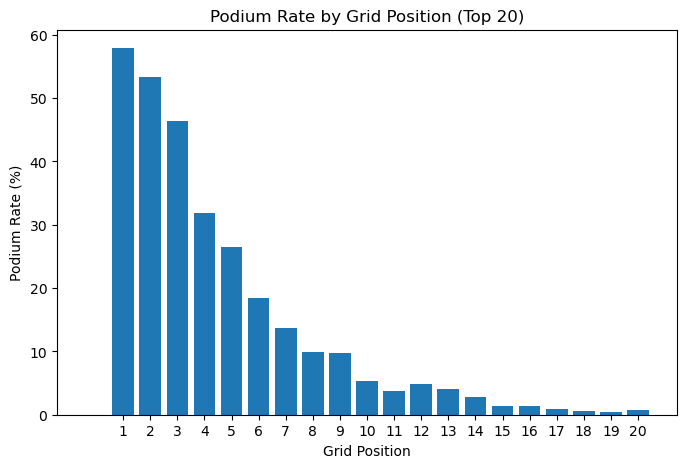

In [88]:
podium_by_grid = df.groupby('grid')['podium'].mean() * 100

top_grids = podium_by_grid[podium_by_grid.index <= 20]

plt.figure(figsize=(8,5))
plt.bar(top_grids.index, top_grids.values)

plt.title('Podium Rate by Grid Position (Top 20)')
plt.xlabel('Grid Position')
plt.ylabel('Podium Rate (%)')

plt.xticks(range(1,21))
plt.show()

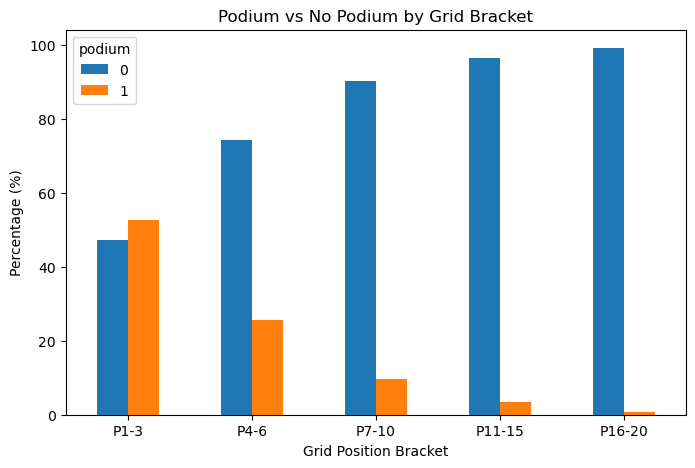

In [89]:
grid_cap = df[df['grid'] <= 20].copy()

grid_cap['grid_bin'] = pd.cut(
    grid_cap['grid'],
    bins=[0,3,6,10,15,20],
    labels=['P1-3','P4-6','P7-10','P11-15','P16-20']
)

pct = grid_cap.groupby(['grid_bin', 'podium']).size().unstack(fill_value=0)

pct_pct = pct.div(pct.sum(axis=1), axis=0) * 100

pct_pct.plot(kind='bar', figsize=(8,5))

plt.title('Podium vs No Podium by Grid Bracket')
plt.xlabel('Grid Position Bracket')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)

plt.show()

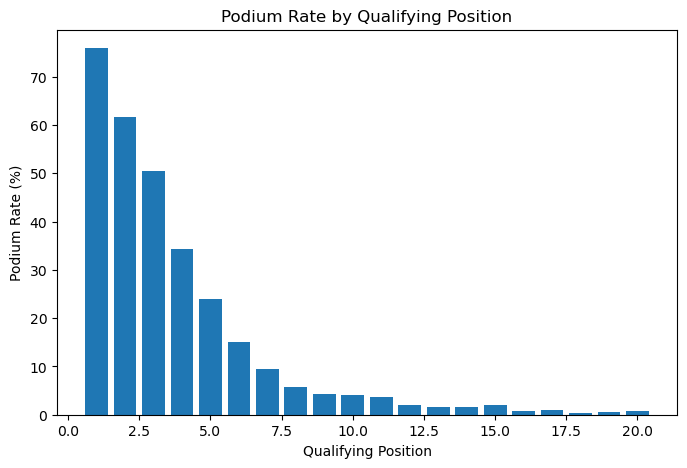

In [90]:
df_q = df[df['quali_position'].notna() & (df['quali_position'] <= 20)]

podium_by_quali = df_q.groupby('quali_position')['podium'].mean() * 100

plt.figure(figsize=(8,5))
plt.bar(podium_by_quali.index, podium_by_quali.values)

plt.title('Podium Rate by Qualifying Position')
plt.xlabel('Qualifying Position')
plt.ylabel('Podium Rate (%)')

plt.show()

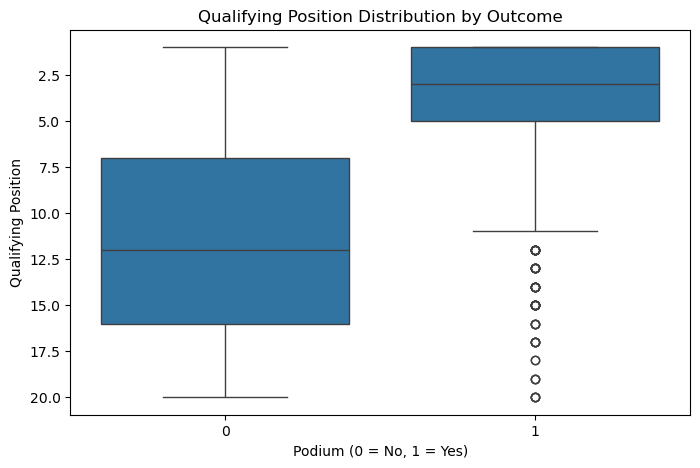

In [91]:
df_q = df[df['quali_position'].notna() & (df['quali_position'] <= 20)]

plt.figure(figsize=(8,5))
sns.boxplot(data=df_q, x='podium', y='quali_position')

plt.title('Qualifying Position Distribution by Outcome')
plt.xlabel('Podium (0 = No, 1 = Yes)')
plt.ylabel('Qualifying Position')

plt.gca().invert_yaxis()

plt.show()

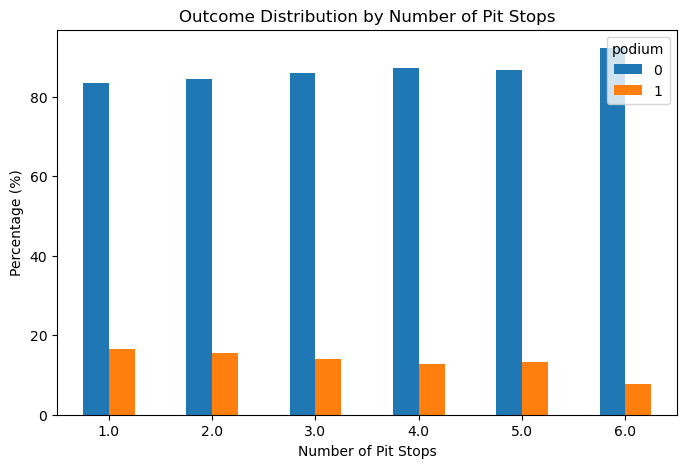

In [92]:
df_pit = df[df['num_pitstops'].notna()]

pit_podium = df_pit.groupby(['num_pitstops', 'podium']).size().unstack(fill_value=0)
pit_podium_pct = pit_podium.div(pit_podium.sum(axis=1), axis=0) * 100

valid_stops = pit_podium_pct[pit_podium_pct.index <= 6]

valid_stops.plot(kind='bar', figsize=(8,5))

plt.title('Outcome Distribution by Number of Pit Stops')
plt.xlabel('Number of Pit Stops')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)

plt.show()

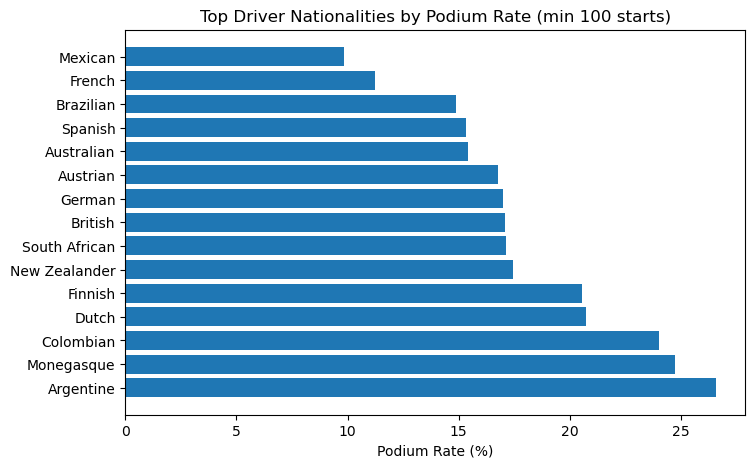

In [93]:
top_nat = df.groupby('nationality')['podium'].agg(['sum', 'count'])

top_nat['rate'] = top_nat['sum'] / top_nat['count'] * 100

top_nat = top_nat[top_nat['count'] >= 100].nlargest(15, 'rate')

plt.figure(figsize=(8,5))
plt.barh(top_nat.index, top_nat['rate'])

plt.title('Top Driver Nationalities by Podium Rate (min 100 starts)')
plt.xlabel('Podium Rate (%)')

plt.show()

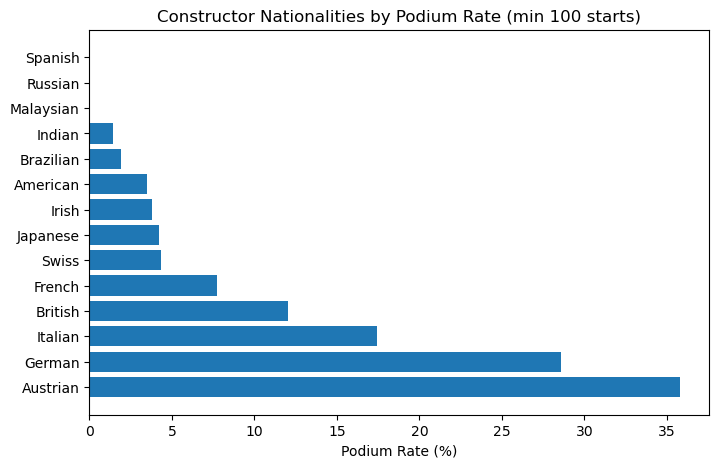

In [94]:
top_con = df.groupby('construct_nationality')['podium'].agg(['sum', 'count'])

top_con['rate'] = top_con['sum'] / top_con['count'] * 100

top_con = top_con[top_con['count'] >= 100].nlargest(15, 'rate')

plt.figure(figsize=(8,5))
plt.barh(top_con.index, top_con['rate'])

plt.title('Constructor Nationalities by Podium Rate (min 100 starts)')
plt.xlabel('Podium Rate (%)')

plt.show()

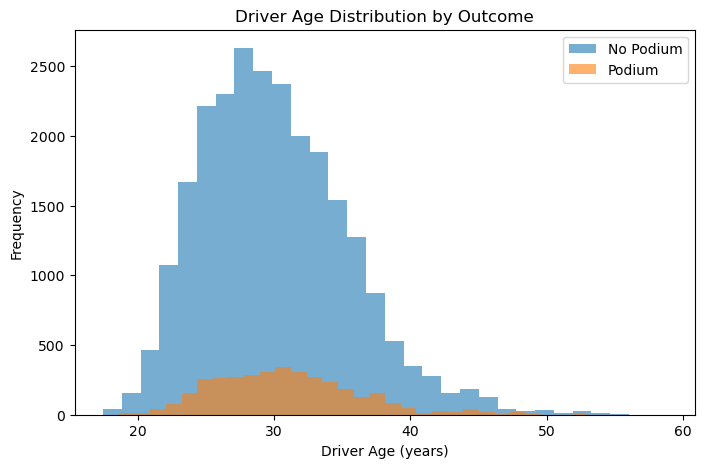

In [95]:
plt.figure(figsize=(8,5))

plt.hist(df[df['podium'] == 0]['driver_age'], bins=30, alpha=0.6, label='No Podium')
plt.hist(df[df['podium'] == 1]['driver_age'], bins=30, alpha=0.6, label='Podium')

plt.title('Driver Age Distribution by Outcome')
plt.xlabel('Driver Age (years)')
plt.ylabel('Frequency')
plt.legend()

plt.show()

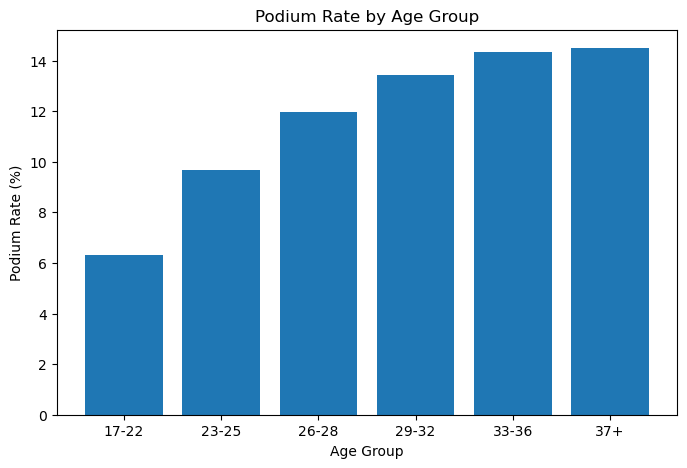

In [96]:
df['age_bin'] = pd.cut(
    df['driver_age'],
    bins=[17, 22, 25, 28, 32, 36, 50],
    labels=['17-22', '23-25', '26-28', '29-32', '33-36', '37+']
)

age_rate = df.groupby('age_bin')['podium'].mean() * 100

plt.figure(figsize=(8,5))
plt.bar(age_rate.index, age_rate.values)

plt.title('Podium Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Podium Rate (%)')

plt.show()

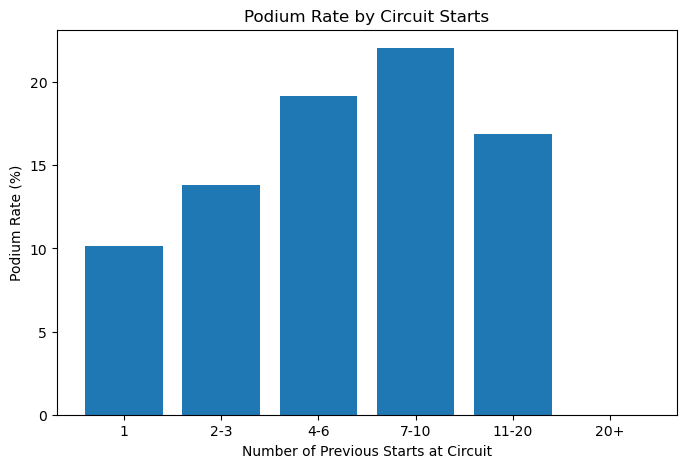

In [97]:
df['starts_bin'] = pd.cut(
    df['circuit_starts'],
    bins=[0,1,3,6,10,20,100],
    labels=['1','2-3','4-6','7-10','11-20','20+']
)

starts_rate = df.groupby('starts_bin')['podium'].mean() * 100

plt.figure(figsize=(8,5))
plt.bar(starts_rate.index, starts_rate.values)

plt.title('Podium Rate by Circuit Starts')
plt.xlabel('Number of Previous Starts at Circuit')
plt.ylabel('Podium Rate (%)')

plt.show()

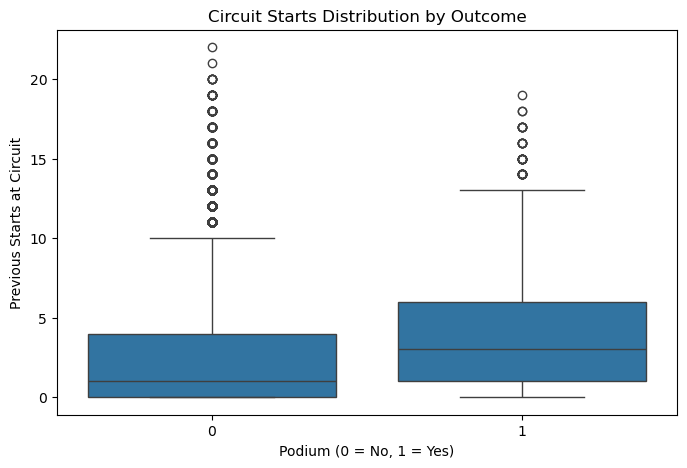

In [98]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='podium', y='circuit_starts')

plt.title('Circuit Starts Distribution by Outcome')
plt.xlabel('Podium (0 = No, 1 = Yes)')
plt.ylabel('Previous Starts at Circuit')

plt.show()

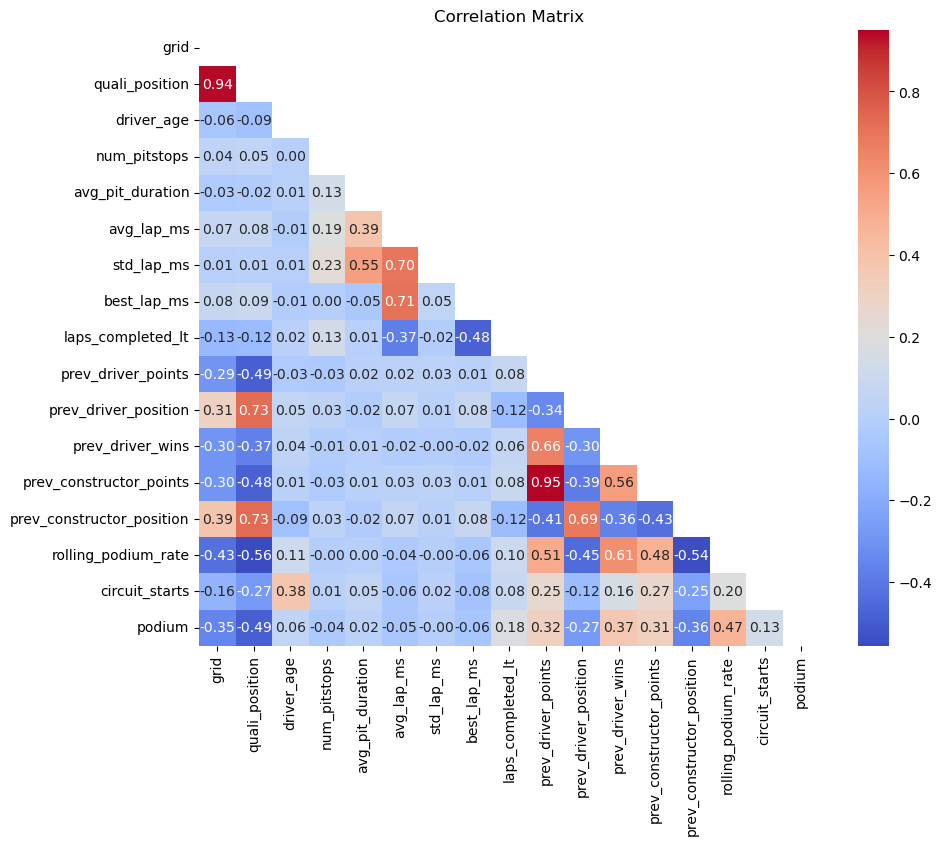

In [99]:
numeric_cols = [
    'grid', 'quali_position', 'driver_age', 'num_pitstops', 'avg_pit_duration',
    'avg_lap_ms', 'std_lap_ms', 'best_lap_ms', 'laps_completed_lt',
    'prev_driver_points', 'prev_driver_position', 'prev_driver_wins',
    'prev_constructor_points', 'prev_constructor_position',
    'rolling_podium_rate', 'circuit_starts', 'podium'
]
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10,8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

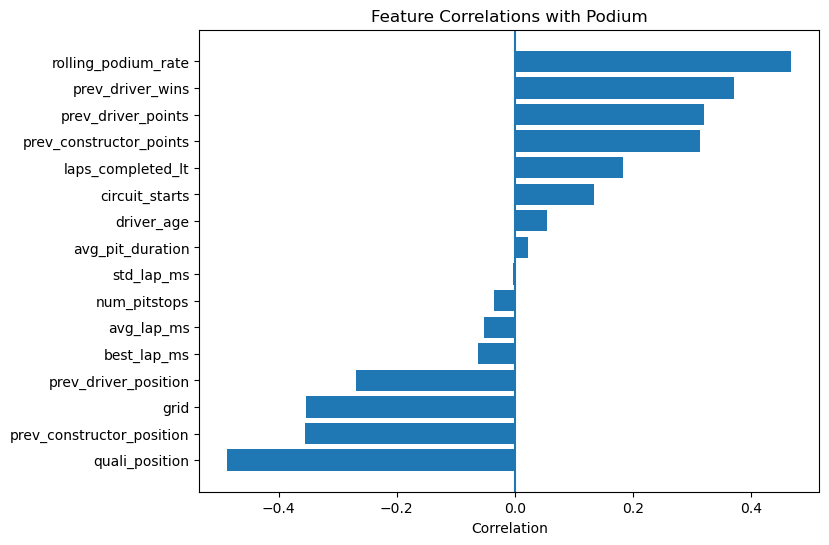

In [100]:
podium_corr = df[numeric_cols].corr()['podium'].drop('podium').sort_values()
plt.figure(figsize=(8,6))
plt.barh(podium_corr.index, podium_corr.values)
plt.axvline(0)
plt.title('Feature Correlations with Podium')
plt.xlabel('Correlation')
plt.show()

### MISSING VALUE ANALYSIS

In [101]:
feature_cols = ['grid','quali_position','driver_age','num_pitstops','avg_pit_duration',
                'min_pit_duration','avg_lap_ms','std_lap_ms','best_lap_ms',
                'prev_driver_points','prev_driver_position','prev_driver_wins',
                'prev_constructor_points','prev_constructor_position',
                'rolling_podium_rate','circuit_starts']

miss = df[feature_cols].isnull().mean().sort_values(ascending=False)
print('Missing value rates:')
print(miss[miss > 0])

Missing value rates:
num_pitstops                 0.803233
avg_pit_duration             0.803233
min_pit_duration             0.803233
quali_position               0.629619
std_lap_ms                   0.614372
avg_lap_ms                   0.610313
best_lap_ms                  0.610313
prev_constructor_points      0.126496
prev_constructor_position    0.126496
prev_driver_points           0.048812
prev_driver_position         0.048812
prev_driver_wins             0.048812
rolling_podium_rate          0.031377
dtype: float64


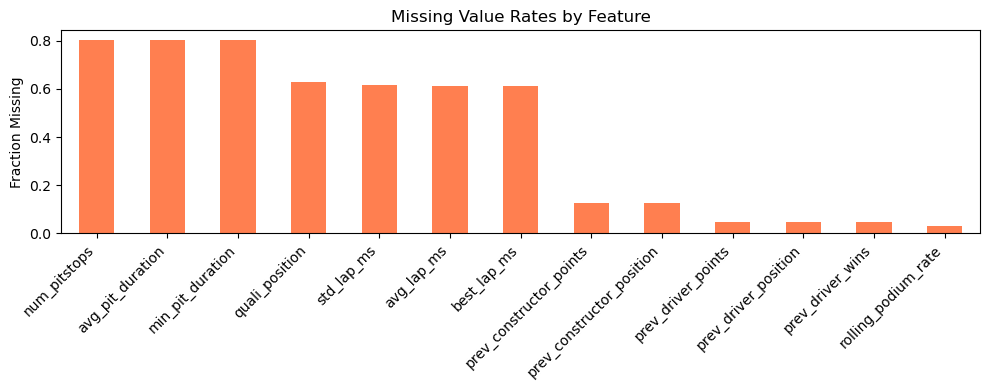

In [102]:
plt.figure(figsize=(10,4))
miss[miss > 0].plot(kind='bar', color='coral')
plt.title('Missing Value Rates by Feature')
plt.ylabel('Fraction Missing')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Create a new dataset (model_df) with only:

feature_cols →  input features

constructorId, circuitId → categorical features

year → for time-based split

podium → target variable

Removes unnecessary columns → cleaner dataset for ML

For each numeric column: Replaces missing values (NaN) with median
Example: [1, 2, 100, NaN] → median = 2 → NaN becomes 2

LabelEncoder converts categories into numbers
Example: Ferrari → 0
         Mercedes → 1
         Red Bull → 2

feature_final = all features used for prediction

Train → past data (before 2020)
Test → future data (2020 onwards)

In [103]:
model_df = df[feature_cols + ['constructorId','circuitId','year','podium']].copy()

In [104]:
for col in feature_cols:
    if model_df[col].dtype in [np.float64, np.int64]:
        model_df[col].fillna(model_df[col].median(), inplace=True)

for col in ['constructorId', 'circuitId']:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col].astype(str))

In [105]:
feature_final = feature_cols + ['constructorId', 'circuitId']

train = model_df[model_df['year'] < 2020]
test  = model_df[model_df['year'] >= 2020]

X_train, y_train = train[feature_final], train['podium']
X_test,  y_test  = test[feature_final],  test['podium']

print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')
print(f'Train podium rate: {y_train.mean():.3f}')
print(f'Test podium rate:  {y_test.mean():.3f}')

Train size: (26194, 18), Test size: (2139, 18)
Train podium rate: 0.125
Test podium rate:  0.150
